In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns 
import plotly.graph_objects as go
import matplotlib.pyplot as plt




In [2]:
customer_journey = pd.read_csv(r"C:\Users\Interface\Downloads\archive (3)\customer_journey.csv")

In [3]:
customer_journey.tail()

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
12714,session_4996,user_1354,2025-07-11 10:21:00,product_page,Desktop,Germany,Email,77,0,0
12715,session_4997,user_2646,2025-05-27 19:54:51,home,Desktop,Germany,Social Media,57,0,0
12716,session_4998,user_1040,2025-01-07 04:26:16,home,Tablet,Germany,Google,167,0,0
12717,session_4998,user_1040,2025-01-07 04:26:54,product_page,Tablet,Germany,Google,38,2,0
12718,session_4999,user_1541,2025-05-24 05:09:58,home,Mobile,Germany,Social Media,113,0,0


In [4]:
customer_journey.shape

(12719, 10)

In [5]:
customer_journey.dtypes

SessionID             object
UserID                object
Timestamp             object
PageType              object
DeviceType            object
Country               object
ReferralSource        object
TimeOnPage_seconds     int64
ItemsInCart            int64
Purchased              int64
dtype: object

In [6]:
for col in customer_journey.columns:
    print(col)
    print(customer_journey[col].unique())
    print(customer_journey[col].nunique())
    print("-" * 50)

SessionID
['session_0' 'session_1' 'session_2' ... 'session_4997' 'session_4998'
 'session_4999']
5000
--------------------------------------------------
UserID
['user_2223' 'user_2192' 'user_1708' ... 'user_1175' 'user_1434'
 'user_2587']
1872
--------------------------------------------------
Timestamp
['2025-01-20 22:53:34' '2025-02-26 12:57:10' '2025-02-26 12:59:11' ...
 '2025-01-07 04:26:16' '2025-01-07 04:26:54' '2025-05-24 05:09:58']
12713
--------------------------------------------------
PageType
['home' 'product_page' 'cart' 'checkout' 'confirmation']
5
--------------------------------------------------
DeviceType
['Desktop' 'Tablet' 'Mobile']
3
--------------------------------------------------
Country
['India' 'Germany' 'UK' 'France' 'Australia' 'USA' 'Canada']
7
--------------------------------------------------
ReferralSource
['Social Media' 'Email' 'Google' 'Direct']
4
--------------------------------------------------
TimeOnPage_seconds
[ 55  99 121 160 113  49 135 155 

In [7]:
customer_journey.describe()

,TimeOnPage_seconds,ItemsInCart,Purchased
count,12719.000000,12719.000000,12719.000000
mean,97.427707,1.138533,0.397044
std,48.120729,1.689954,0.489304
min,15.000000,0.000000,0.000000
25%,56.000000,0.000000,0.000000
50%,98.000000,0.000000,0.000000
75%,139.000000,2.000000,1.000000
max,180.000000,5.000000,1.000000


In [8]:
customer_journey.isnull().sum()

SessionID             0
UserID                0
Timestamp             0
PageType              0
DeviceType            0
Country               0
ReferralSource        0
TimeOnPage_seconds    0
ItemsInCart           0
Purchased             0
dtype: int64

In [9]:
customer_journey.duplicated().sum

<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
12714    False
12715    False
12716    False
12717    False
12718    False
Length: 12719, dtype: bool>

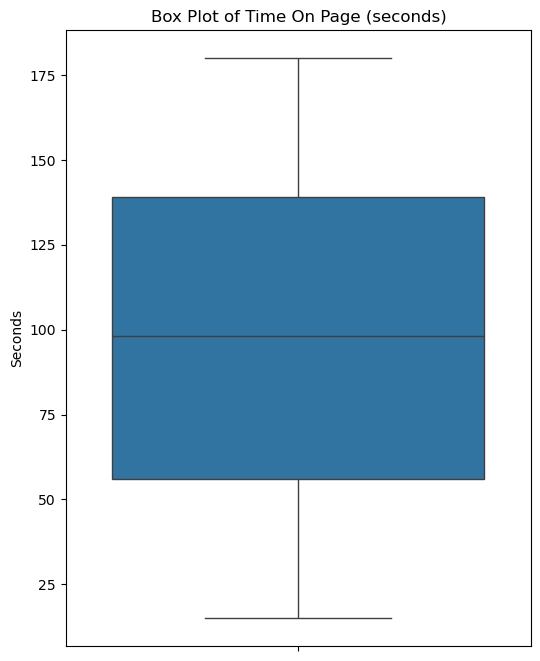

In [10]:
plt.figure(figsize=(6,8))

sns.boxplot(y=customer_journey["TimeOnPage_seconds"])

plt.title("Box Plot of Time On Page (seconds)")
plt.ylabel("Seconds")

plt.show()

In [11]:
customer_journey['Timestamp'] = pd.to_datetime(customer_journey['Timestamp'])

In [12]:
customer_journey['Date'] = customer_journey['Timestamp'].dt.date
customer_journey['Time'] = customer_journey['Timestamp'].dt.time

In [13]:
session_level = customer_journey.groupby(['UserID', 'SessionID']).agg(
    Purchased=('Purchased', 'max') 
).reset_index()

In [14]:
user_metrics = session_level.groupby('UserID').agg(
    TotalSessionsPerUser=('SessionID', 'nunique'),
    PurchaseCountsPerUser=('Purchased', 'sum')
).reset_index()

In [15]:
customer_journey = customer_journey.merge(user_metrics, on='UserID', how='left')

In [16]:
customer_journey

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased,Date,Time,TotalSessionsPerUser,PurchaseCountsPerUser
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0,2025-01-20,22:53:34,4,1
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0,2025-02-26,12:57:10,5,1
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0,2025-02-26,12:59:11,5,1
3,session_2,user_1708,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0,2025-06-24,15:40:46,5,1
4,session_3,user_2976,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0,2025-06-11,07:21:02,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12714,session_4996,user_1354,2025-07-11 10:21:00,product_page,Desktop,Germany,Email,77,0,0,2025-07-11,10:21:00,3,1
12715,session_4997,user_2646,2025-05-27 19:54:51,home,Desktop,Germany,Social Media,57,0,0,2025-05-27,19:54:51,3,0
12716,session_4998,user_1040,2025-01-07 04:26:16,home,Tablet,Germany,Google,167,0,0,2025-01-07,04:26:16,3,1
12717,session_4998,user_1040,2025-01-07 04:26:54,product_page,Tablet,Germany,Google,38,2,0,2025-01-07,04:26:54,3,1


In [17]:
customer_journey_grouped = customer_journey.groupby('UserID').agg({
    'TotalSessionsPerUser': 'max',
    'PurchaseCountsPerUser': 'max'
}).reset_index()

customer_journey_grouped

,UserID,TotalSessionsPerUser,PurchaseCountsPerUser
0,user_1001,2,1
1,user_1002,2,1
2,user_1004,1,0
3,user_1005,2,2
4,user_1006,4,0
...,...,...,...
1867,user_2997,5,0
1868,user_2998,1,0
1869,user_2999,3,1
1870,user_3000,3,3


In [18]:
print(customer_journey_grouped['TotalSessionsPerUser'].unique())

print(customer_journey_grouped['PurchaseCountsPerUser'].unique())

[ 2  1  4  3  6  7  5  9  8 10]
[1 0 2 3 4]


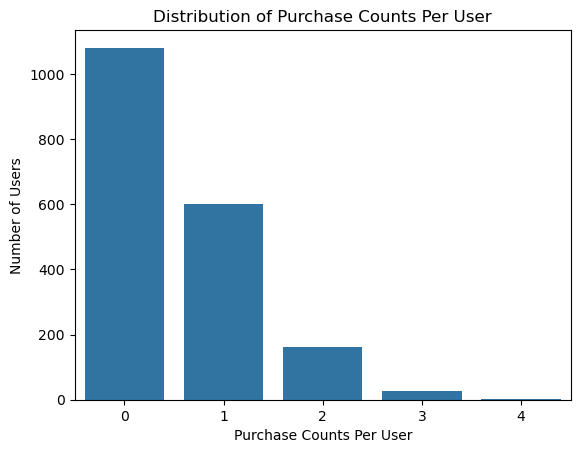

In [19]:
sns.countplot(
    x='PurchaseCountsPerUser',
    data=customer_journey_grouped
)

plt.title('Distribution of Purchase Counts Per User')
plt.xlabel('Purchase Counts Per User')
plt.ylabel('Number of Users')

plt.show()

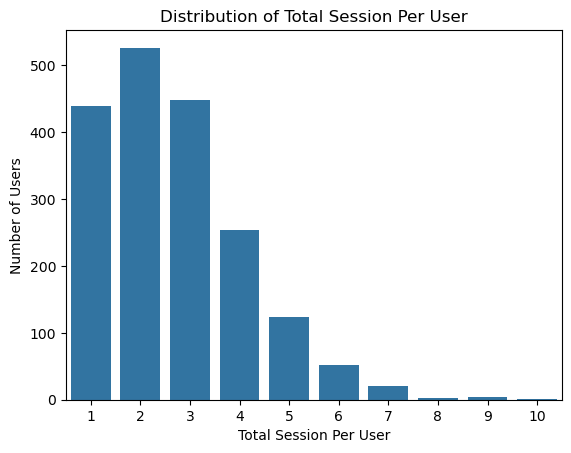

In [20]:
sns.countplot(
    x='TotalSessionsPerUser',
    data=customer_journey_grouped
)

plt.title('Distribution of Total Session Per User')
plt.xlabel('Total Session Per User')
plt.ylabel('Number of Users')

plt.show()

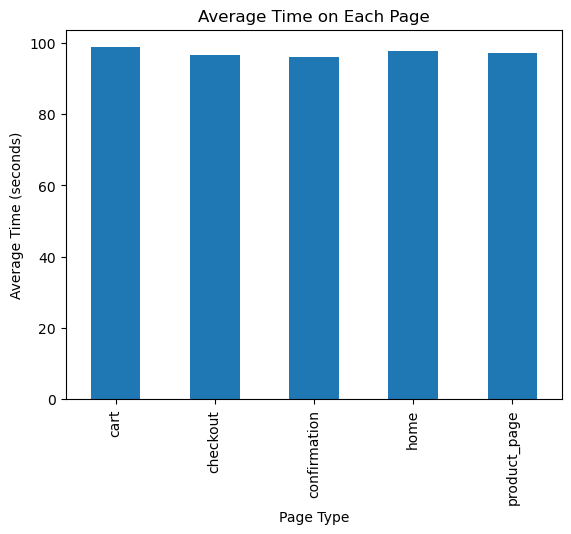

In [21]:
avg_time = customer_journey.groupby(
    'PageType'
)['TimeOnPage_seconds'].mean()

avg_time.plot(kind='bar')

plt.title('Average Time on Each Page')
plt.xlabel('Page Type')
plt.ylabel('Average Time (seconds)')

plt.show()

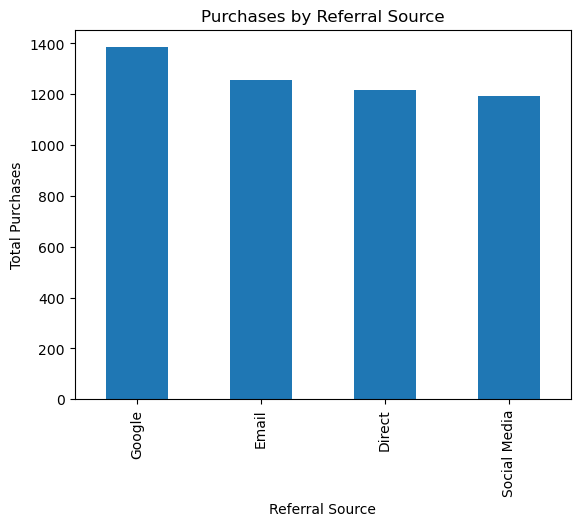

In [22]:
purchase_by_source = customer_journey.groupby(
    'ReferralSource'
)['Purchased'].sum().sort_values(ascending=False)

purchase_by_source.plot(kind='bar')

plt.title('Purchases by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Total Purchases')

plt.show()

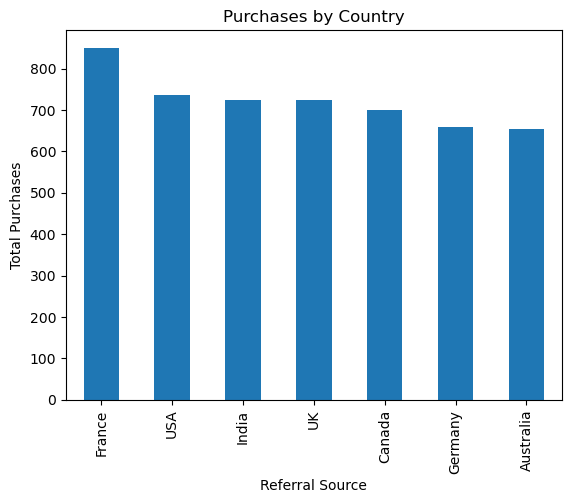

In [23]:
Country = customer_journey.groupby(
    'Country'
)['Purchased'].sum().sort_values(ascending=False)

Country.plot(kind='bar')

plt.title('Purchases by Country')
plt.xlabel('Referral Source')
plt.ylabel('Total Purchases')

plt.show()

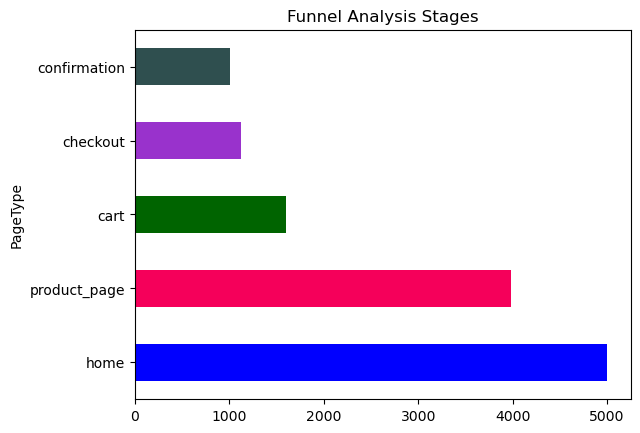

In [24]:

customer_journey["PageType"].value_counts().plot.barh(color=['blue', '#f5005a', '#006400', '#9932CC', '#2F4F4F', '#1E90FF' ], title='Funnel Analysis Stages');

In [25]:
dfgr = customer_journey.groupby('PageType').count()['Purchased'].reset_index().sort_values(by='Purchased',ascending=False)
dfgr.style.background_gradient(cmap='PuOr')

,PageType,Purchased
3,home,5000
4,product_page,3987
0,cart,1599
1,checkout,1123
2,confirmation,1010


In [26]:
stages = ['Homepage', 'Product Page', 'Cart', 'Checkout', 'confirmation']
values = [5000, 3987, 1599, 1123, 1010]

fig = go.Figure(go.Funnel(
    y=stages,
    x=values,
    textinfo="value+percent initial"
))

fig.update_layout(
    title='E-commerce Funnel Analysis',
    width=900,
    height=500
)

fig.show()

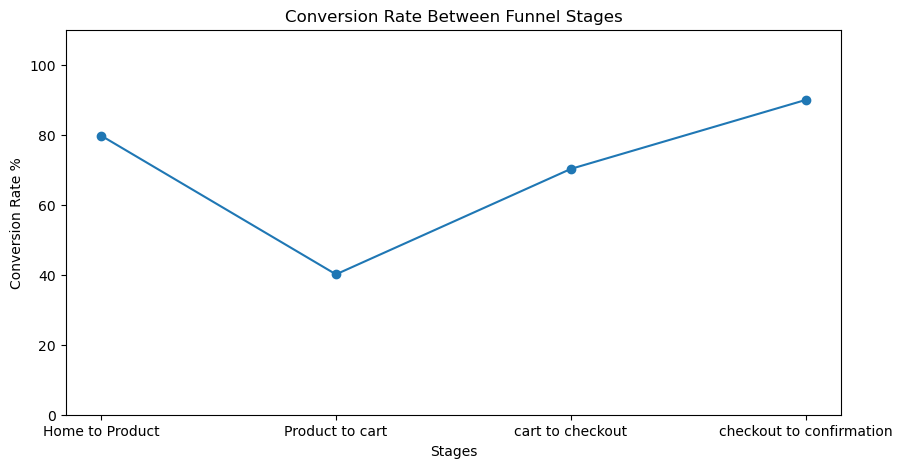

In [27]:

stages = [ 'Home to Product', 'Product to cart', 'cart to checkout', 'checkout to confirmation']
values = [3987, 1599, 1123, 1010]

conversion_rates = [
    (3987 / 5000) * 100,
    (1599 / 3987) * 100,
    (1123 / 1599) * 100,
    (1010 / 1123) * 100
]

plt.figure(figsize=(10,5))

plt.plot(stages, conversion_rates, marker='o')

plt.title('Conversion Rate Between Funnel Stages')
plt.xlabel('Stages')
plt.ylabel('Conversion Rate %')

plt.ylim(0, 110)

plt.show()

In [28]:


df = customer_journey.copy()

df['PageType'] = df['PageType'].str.strip().str.lower()
df['DeviceType'] = df['DeviceType'].str.strip().str.lower()

devices = df['DeviceType'].unique()

stages = ['home', 'product_page', 'cart', 'checkout', 'Confirmation']

fig = go.Figure()

for device in devices:
    
    df_d = df[df['DeviceType'] == device]

    home = df_d[df_d['PageType'] == 'home']['UserID'].count()
    product = df_d[df_d['PageType'] == 'product_page']['UserID'].count()
    cart = df_d[df_d['PageType'] == 'cart']['UserID'].count()
    checkout = df_d[df_d['PageType'] == 'checkout']['UserID'].count()
    confirmation = df_d[df_d['PageType'] == 'confirmation']['UserID'].count()

    fig.add_trace(go.Funnel(
        name=device,
        y=stages,
        x=[home, product, cart, checkout, confirmation],
        textinfo="value+percent initial"
    ))

fig.update_layout(
    title="Funnel Analysis by Device Type",
    height=600
)

fig.show()

In [29]:
df = customer_journey.copy()

df['PageType'] = df['PageType'].str.strip().str.lower()
df['Country'] = df['Country'].str.strip().str.lower()

countries = df['Country'].unique()

stages = ['home', 'product_page', 'cart', 'checkout', 'Confirmation']

fig = go.Figure()

for country in countries:
    
    df_d = df[df['Country'] == country]

    home = df_d[df_d['PageType'] == 'home']['UserID'].count()
    product = df_d[df_d['PageType'] == 'product_page']['UserID'].count()
    cart = df_d[df_d['PageType'] == 'cart']['UserID'].count()
    checkout = df_d[df_d['PageType'] == 'checkout']['UserID'].count()
    confirmation = df_d[df_d['PageType'] == 'confirmation']['UserID'].count()

    fig.add_trace(go.Funnel(
        name=country,
        y=stages,
        x=[home, product, cart, checkout, confirmation],
        textinfo="value+percent initial"
    ))

fig.update_layout(
    title="Funnel Analysis by Countries",
    height=600,
    width=1050
)

fig.show()

In [30]:
import pandas as pd

# استخراج الساعة
customer_journey['Hour'] = pd.to_datetime(
    customer_journey['Time'],
    format='%H:%M:%S',
    errors='coerce'
).dt.hour

# إنشاء عمود TimeSegment داخل الجدول نفسه
customer_journey['TimeSegment'] = pd.cut(
    customer_journey['Hour'],
    bins=[0, 4, 8, 12, 16, 20, 24],
    labels=[
        'Late Night',
        'Early Morning',
        'Morning',
        'Afternoon',
        'Evening',
        'Night'
    ],
    right=False,
    include_lowest=True
)

customer_journey.head()

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased,Date,Time,TotalSessionsPerUser,PurchaseCountsPerUser,Hour,TimeSegment
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0,2025-01-20,22:53:34,4,1,22,Night
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0,2025-02-26,12:57:10,5,1,12,Afternoon
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0,2025-02-26,12:59:11,5,1,12,Afternoon
3,session_2,user_1708,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0,2025-06-24,15:40:46,5,1,15,Afternoon
4,session_3,user_2976,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0,2025-06-11,07:21:02,1,0,7,Early Morning


In [31]:
df = customer_journey.copy()

df['PageType'] = df['PageType'].str.strip().str.lower()
df['TimeSegment'] = df['TimeSegment'].str.strip().str.lower()

Segments = df['TimeSegment'].unique()

stages = ['home', 'product_page', 'cart', 'checkout', 'Confirmation']

fig = go.Figure()

for Segment in Segments:
    
    df_d = df[df['TimeSegment'] == Segment]

    home = df_d[df_d['PageType'] == 'home']['UserID'].count()
    product = df_d[df_d['PageType'] == 'product_page']['UserID'].count()
    cart = df_d[df_d['PageType'] == 'cart']['UserID'].count()
    checkout = df_d[df_d['PageType'] == 'checkout']['UserID'].count()
    confirmation = df_d[df_d['PageType'] == 'confirmation']['UserID'].count()

    fig.add_trace(go.Funnel(
        name=Segment,
        y=stages,
        x=[home, product, cart, checkout, confirmation],
        textinfo="value+percent initial"
    ))

fig.update_layout(
    title="Funnel Analysis by Time Segment",
    height=600,
    width=1050
)

fig.show()